# Bloom / CEP - ingestao dos QA pairs

Le os artefatos `*_cep_qa.json` de `results/<RUN_ID>/cep/outputs/`
(`RUN_ID` default `thesis-run-01`, sobrescrevivel pela env `ARANDU_RUN_ID`) e monta
um `DataFrame` com **uma linha por par QA**, achatando:

- metadados da fonte (`source_*`, arquivo, local, data da gravacao);
- campos de geracao do par (bloom, tipo, multi-hop, chunk);
- os criterios do validador CEP (`faithfulness`, `bloom_calibration`,
  `informativeness`, `self_containedness`) em colunas `score_*` / `thr_*`.

Requer o extra `analysis` (pandas): `uv sync --extra analysis`.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS_ROOT = Path(os.environ.get("ARANDU_RESULTS_BASE_DIR", REPO_ROOT / "results"))

# Parametro do notebook: troque o run-id (ou exporte ARANDU_RUN_ID) para
# analisar outra execucao sem tocar no resto das celulas.
RUN_ID = os.environ.get("ARANDU_RUN_ID", "thesis-run-01")


def cep_outputs_dir(run_id: str = RUN_ID, results_root: Path = RESULTS_ROOT) -> Path:
    """Resolve o diretorio de saidas do estagio CEP de um run.

    Args:
        run_id: Identificador do run em `results/`.
        results_root: Raiz do diretorio de resultados.

    Returns:
        Caminho `results/<run-id>/cep/outputs/`.
    """
    return results_root / run_id / "cep" / "outputs"


def available_runs(results_root: Path = RESULTS_ROOT) -> list[str]:
    """Lista os run-ids que possuem saidas do estagio CEP.

    Args:
        results_root: Raiz do diretorio de resultados.

    Returns:
        Run-ids ordenados com ao menos um arquivo `*_cep_qa.json`.
    """
    return sorted(
        path.parent.parent.name
        for path in results_root.glob("*/cep/outputs")
        if any(path.glob("*_cep_qa.json"))
    )


CEP_DIR = cep_outputs_dir()

# Campos de texto longo descartados do DataFrame (ficam so como tamanho).
HEAVY_FIELDS = ("context", "generation_prompt", "generation_thinking")

CEP_FILES = sorted(CEP_DIR.glob("*_cep_qa.json"))
print(f"runs com saida CEP: {available_runs()}")
RUN_ID, CEP_DIR, len(CEP_FILES)

runs com saida CEP: ['thesis-run-01']


('thesis-run-01',
 PosixPath('/home/fred/Workspace/mastering/arandu/results/thesis-run-01/cep/outputs'),
 214)

In [2]:
def _criterion_columns(pair: dict[str, Any]) -> dict[str, Any]:
    """Achata os criterios do validador CEP em colunas planas.

    Args:
        pair: Par QA bruto, como serializado no arquivo `*_cep_qa.json`.

    Returns:
        Mapa com `score_<criterio>` e `thr_<criterio>` para cada criterio
        avaliado, mais `rejected_at` e `passed` do estagio de validacao.
    """
    validation = pair.get("validation") or {}
    stages = validation.get("stage_results") or {}
    scores = (stages.get("cep_validation") or {}).get("criterion_scores") or {}

    columns: dict[str, Any] = {
        "passed": validation.get("passed"),
        "rejected_at": validation.get("rejected_at"),
    }
    for name, criterion in scores.items():
        columns[f"score_{name}"] = criterion.get("score")
        columns[f"thr_{name}"] = criterion.get("threshold")
    return columns


def _flatten_pair(doc: dict[str, Any], pair: dict[str, Any]) -> dict[str, Any]:
    """Monta a linha de um par QA com os metadados do documento de origem.

    Args:
        doc: Documento `*_cep_qa.json` completo.
        pair: Um item de `doc["qa_pairs"]`.

    Returns:
        Linha plana pronta para virar registro de `DataFrame`.
    """
    meta = doc.get("source_metadata") or {}
    row: dict[str, Any] = {
        "source_gdrive_id": doc.get("source_gdrive_id"),
        "source_filename": doc.get("source_filename"),
        "location": meta.get("location"),
        "recording_date": meta.get("recording_date"),
        "event_context": meta.get("event_context"),
        "extraction_confidence": meta.get("extraction_confidence"),
        "model_id": doc.get("model_id"),
        "validator_model_id": doc.get("validator_model_id"),
        "chunker_id": doc.get("chunker_id"),
        "language": doc.get("language"),
        "cep_version": doc.get("cep_version"),
        "generation_timestamp": doc.get("generation_timestamp"),
        "doc_total_pairs": doc.get("total_pairs"),
        "doc_validated_pairs": doc.get("validated_pairs"),
        "doc_validation_rate": doc.get("validation_rate"),
    }
    row.update({k: v for k, v in pair.items() if k not in HEAVY_FIELDS and k != "validation"})
    row.update({f"{field}_chars": len(pair.get(field) or "") for field in HEAVY_FIELDS})
    row.update(_criterion_columns(pair))
    return row


def load_cep_pairs(cep_dir: Path | None = None) -> pd.DataFrame:
    """Le todos os artefatos CEP de um diretorio e retorna um par QA por linha.

    Args:
        cep_dir: Diretorio `results/<run-id>/cep/outputs/`. Por padrao, o
            do `RUN_ID` corrente.

    Returns:
        `DataFrame` com uma linha por par QA e colunas achatadas de fonte,
        geracao e validacao.

    Raises:
        FileNotFoundError: Se o diretorio nao contiver arquivos `*_cep_qa.json`.
    """
    cep_dir = cep_dir or CEP_DIR
    files = sorted(cep_dir.glob("*_cep_qa.json"))
    if not files:
        raise FileNotFoundError(f"Nenhum *_cep_qa.json em {cep_dir}")

    rows: list[dict[str, Any]] = []
    for path in files:
        doc = json.loads(path.read_text(encoding="utf-8"))
        rows.extend(_flatten_pair(doc, pair) for pair in doc.get("qa_pairs", []))

    df = pd.DataFrame(rows)
    df["generation_timestamp"] = pd.to_datetime(df["generation_timestamp"], errors="coerce")
    for column in ("bloom_level", "question_type", "location", "rejected_at"):
        df[column] = df[column].astype("category")
    return df

In [3]:
df = load_cep_pairs()
print(f"[{RUN_ID}] {df['source_gdrive_id'].nunique()} transcricoes -> {len(df)} pares QA")
df.head()

[thesis-run-01] 214 transcricoes -> 2670 pares QA


,source_gdrive_id,source_filename,location,recording_date,event_context,extraction_confidence,model_id,validator_model_id,chunker_id,language,...,passed,rejected_at,score_faithfulness,thr_faithfulness,score_bloom_calibration,thr_bloom_calibration,score_informativeness,thr_informativeness,score_self_containedness,thr_self_containedness
0,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
1,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
2,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,NaN,NaN,NaN,NaN
3,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,True,NaN,1.00,0.625,1.0,0.625,0.75,0.625,1.00,0.625
4,1-ZWwPv7DM458HviU5UkJgJEHzVXan0la,MVI_8624.MOV,BALSA,23-04-2026,Aida- 23-04-2026 Dani Borges,0.5,qwen3:14b,qwen3:14b,cep_4k,pt,...,False,cep_validation,0.75,0.625,1.0,0.625,0.50,0.625,0.75,0.625


In [4]:
# Conferencia rapida: cobertura das colunas e distribuicoes principais.
display(df.dtypes.to_frame("dtype"))

display(
    df.groupby("bloom_level", observed=True)["is_valid"]
    .agg(pares="size", validos="sum", taxa="mean")
    .sort_values("pares", ascending=False)
)

score_cols = [c for c in df.columns if c.startswith("score_")]
display(df[score_cols].describe().T)

# `informativeness` e `self_containedness` NAO sao avaliados em pares de nivel
# `remember` (ver `qa/cep/judge.py`): nulos ai sao ausencia de criterio, nao
# falha. Nulos em `faithfulness`/`bloom_calibration` indicam erro do juiz.
df[score_cols].isna().mean().to_frame("fracao_nula")

,dtype
source_gdrive_id,object
source_filename,object
location,category
recording_date,object
event_context,object
extraction_confidence,float64
model_id,object
validator_model_id,object
chunker_id,object
language,object


,pares,validos,taxa
bloom_level,,,
remember,1335,1225,0.917603
analyze,445,146,0.328090
evaluate,445,93,0.208989
understand,445,115,0.258427


,count,mean,std,min,25%,50%,75%,max
score_faithfulness,2658.0,0.858916,0.207562,0.00,0.75,1.00,1.00,1.0
score_bloom_calibration,2670.0,0.945787,0.150825,0.00,1.00,1.00,1.00,1.0
score_informativeness,1335.0,0.663670,0.212940,0.25,0.50,0.75,0.75,1.0
score_self_containedness,1335.0,0.698127,0.261498,0.00,0.50,0.75,1.00,1.0


,fracao_nula
score_faithfulness,0.004494
score_bloom_calibration,0.000000
score_informativeness,0.500000
score_self_containedness,0.500000


## Distribuição de aprovações para cada nível de Bloom por critério

Um par é *aprovado* num critério quando `score >= threshold`. Os critérios
`informativeness` e `self_containedness` não são aplicados ao nível `remember`
(ver `qa/cep/judge.py`), então essas células ficam vazias no gráfico: ausência
de avaliação, não reprovação.

In [5]:
CRITERIA = ["faithfulness", "bloom_calibration", "informativeness", "self_containedness"]
BLOOM_ORDER = ["remember", "understand", "analyze", "evaluate"]

CRITERION_LABELS = {
    "faithfulness": "Fidelidade",
    "bloom_calibration": "Calibração Bloom",
    "informativeness": "Informatividade",
    "self_containedness": "Autocontenção",
}
BLOOM_LABELS = {
    "remember": "Lembrar",
    "understand": "Entender",
    "analyze": "Analisar",
    "evaluate": "Avaliar",
}


def criterion_long(df: pd.DataFrame) -> pd.DataFrame:
    """Explode o DataFrame em um registro por (par QA, criterio) avaliado.

    Pares sem o criterio (caso de `informativeness` e `self_containedness` em
    nivel `remember`) nao geram linha, entao ausencia nunca vira zero.

    Args:
        df: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Frame longo com `bloom_level`, `criterion`, `score`, `threshold` e a
        flag `approved` (`score >= threshold`).
    """
    frames = []
    for criterion in CRITERIA:
        score, threshold = f"score_{criterion}", f"thr_{criterion}"
        sub = df.dropna(subset=[score, threshold])
        frames.append(
            pd.DataFrame(
                {
                    "bloom_level": sub["bloom_level"].astype(str),
                    "criterion": criterion,
                    "score": sub[score].to_numpy(),
                    "threshold": sub[threshold].to_numpy(),
                    "approved": (sub[score] >= sub[threshold]).to_numpy(),
                }
            )
        )

    long = pd.concat(frames, ignore_index=True)
    long["bloom_level"] = pd.Categorical(long["bloom_level"], BLOOM_ORDER, ordered=True)
    long["criterion"] = pd.Categorical(long["criterion"], CRITERIA, ordered=True)
    return long


def wilson_interval(successes: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """Intervalo de confianca de Wilson para uma proporcao.

    Preferido ao intervalo normal porque continua valido com taxas proximas de
    0 ou 1, o caso de `bloom_calibration` no nivel `remember`.

    Args:
        successes: Numero de aprovacoes.
        total: Numero de avaliacoes.
        z: Escore normal do nivel de confianca (1.96 = 95%).

    Returns:
        Limites inferior e superior da proporcao.
    """
    if total == 0:
        return (float("nan"), float("nan"))
    p = successes / total
    denom = 1 + z**2 / total
    center = (p + z**2 / (2 * total)) / denom
    margin = z * ((p * (1 - p) / total + z**2 / (4 * total**2)) ** 0.5) / denom
    return (max(0.0, center - margin), min(1.0, center + margin))


def approval_rates(long: pd.DataFrame) -> pd.DataFrame:
    """Agrega a taxa de aprovacao por criterio e nivel de Bloom.

    O resultado e reindexado na grade completa criterio x nivel, de modo que as
    combinacoes nao avaliadas aparecam como `NaN` (e nunca como taxa zero).

    Args:
        long: Frame longo produzido por `criterion_long`.

    Returns:
        Frame indexado por (`criterion`, `bloom_level`) com `avaliados`,
        `aprovados`, `taxa` e o IC 95% de Wilson (`ic_lo`, `ic_hi`).
    """
    grid = pd.MultiIndex.from_product([CRITERIA, BLOOM_ORDER], names=["criterion", "bloom_level"])
    rates = (
        long.groupby(["criterion", "bloom_level"], observed=True)["approved"]
        .agg(avaliados="size", aprovados="sum")
        .reindex(grid)
    )
    rates["taxa"] = rates["aprovados"] / rates["avaliados"]
    rates[["ic_lo", "ic_hi"]] = [
        wilson_interval(k, n) if pd.notna(n) else (float("nan"), float("nan"))
        for k, n in zip(rates["aprovados"], rates["avaliados"])
    ]
    return rates


long = criterion_long(df)
approval = approval_rates(long)
approval

avaliados  aprovados      taxa     ic_lo  \
criterion          bloom_level                                             
faithfulness       remember        1323.0     1225.0  0.925926  0.910547   
                   understand       445.0      395.0  0.887640  0.854918   
                   analyze          445.0      373.0  0.838202  0.801115   
                   evaluate         445.0      347.0  0.779775  0.738968   
bloom_calibration  remember        1335.0     1334.0  0.999251  0.995769   
                   understand       445.0      424.0  0.952809  0.928937   
                   analyze          445.0      423.0  0.950562  0.926283   
                   evaluate         445.0      355.0  0.797753  0.757956   
informativeness    remember           NaN        NaN       NaN       NaN   
                   understand       445.0      257.0  0.577528  0.531162   
                   analyze          445.0      263.0  0.591011  0.544741   
                   evaluate         445.0      239.0  0.537079  0.490630   
self_containedness remember           NaN        NaN       NaN       NaN   
                   understand       445.0      223.0  0.501124  0.454857   
                   analyze          445.0      296.0  0.665169  0.620072   
                   evaluate         445.0      268.0  0.602247  0.556084   

                                   ic_hi  
criterion          bloom_level            
faithfulness       remember     0.938838  
                   understand   0.913727  
                   analyze      0.869500  
                   evaluate     0.815793  
bloom_calibration  remember     0.999868  
                   understand   0.968930  
                   analyze      0.967128  
                   evaluate     0.832452  
informativeness    remember          NaN  
                   understand   0.622567  
                   analyze      0.635723  
                   evaluate     0.582892  
self_containedness remember          NaN  
                   understand   0.547371  
                   analyze      0.707438  
                   evaluate     0.646660

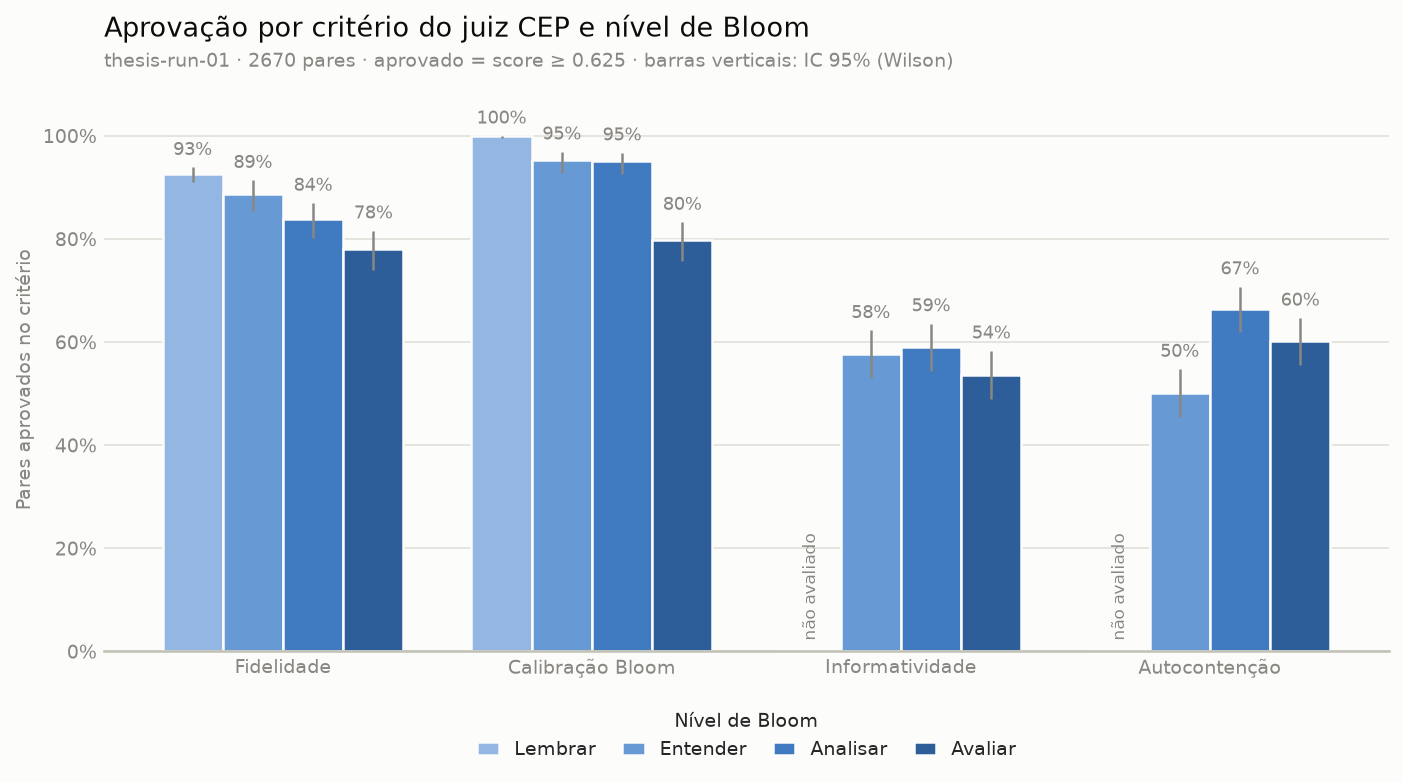

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.ticker import PercentFormatter

# Rampa ordinal de um unico tom: o escurecimento acompanha a ordem de Bloom,
# entao a cor reforca a leitura em vez de depender so da legenda.
BLOOM_RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]
INK, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BAR_WIDTH = 0.78

sns.set_theme(style="white", context="notebook", font_scale=0.95)


def plot_approval(
    rates: pd.DataFrame,
    *,
    ymin: float = 0.0,
    figsize: tuple[float, float] = (9.5, 5.4),
    title: str | None = None,
    subtitle: str | None = None,
    label_size: float = 8.5,
) -> tuple[Figure, Axes]:
    """Desenha a taxa de aprovacao por criterio, agrupada por nivel de Bloom.

    Args:
        rates: Frame no formato de `approval_rates`, indexado por
            (`criterion`, `bloom_level`).
        ymin: Inicio do eixo y. Acima de zero as barras deixam de ser
            proporcionais ao valor: use so quando o rotulo numerico estiver
            visivel em todas as barras.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite (caso de figura com legenda
            externa, em artigo).
        subtitle: Linha de procedencia sob o titulo. `None` omite.
        label_size: Corpo dos rotulos de valor.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    plot_df = rates.reset_index().assign(
        criterio=lambda t: pd.Categorical(
            t["criterion"].map(CRITERION_LABELS),
            [CRITERION_LABELS[c] for c in CRITERIA],
            ordered=True,
        ),
        nivel=lambda t: pd.Categorical(
            t["bloom_level"].map(BLOOM_LABELS),
            [BLOOM_LABELS[b] for b in BLOOM_ORDER],
            ordered=True,
        ),
        # As celulas nao avaliadas viram barra de altura zero (invisivel) apenas
        # para o seaborn reservar a posicao; elas recebem rotulo proprio abaixo.
        altura=lambda t: t["taxa"].fillna(0.0),
    )

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    sns.barplot(
        data=plot_df,
        x="criterio",
        y="altura",
        hue="nivel",
        palette=BLOOM_RAMP,
        edgecolor=SURFACE,
        linewidth=1.2,
        width=BAR_WIDTH,
        ax=ax,
    )

    top = 1.0 + (1.0 - ymin) * 0.055
    # Um BarContainer por nivel de Bloom, cada um com um patch por criterio, na
    # ordem de `CRITERIA`: da para casar patch e linha da tabela sem adivinhar x.
    for container, level in zip(ax.containers, BLOOM_ORDER):
        for patch, criterion in zip(container.patches, CRITERIA):
            row = rates.loc[(criterion, level)]
            x = patch.get_x() + patch.get_width() / 2
            if pd.isna(row["taxa"]):
                ax.text(
                    x, ymin + (top - ymin) * 0.02, "não avaliado", rotation=90,
                    ha="center", va="bottom", fontsize=label_size - 0.5, color=MUTED,
                )
                continue
            ax.vlines(x, row["ic_lo"], row["ic_hi"], color=MUTED, linewidth=1.2)
            ax.text(
                x, row["ic_hi"] + (top - ymin) * 0.015, f"{row['taxa']:.0%}",
                ha="center", va="bottom", fontsize=label_size, color=MUTED,
            )

    ax.set_ylim(ymin, top)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlabel("")
    ax.set_ylabel("Pares aprovados no critério", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=34)
    if subtitle:
        ax.text(0, 1.075, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    ax.legend(
        title="Nível de Bloom", frameon=False, ncol=4, loc="upper center",
        bbox_to_anchor=(0.5, -0.08), fontsize=9, title_fontsize=9,
        columnspacing=1.4, handlelength=1.2,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_approval(
    approval,
    title="Aprovação por critério do juiz CEP e nível de Bloom",
    subtitle=(
        f"{RUN_ID} · {len(df)} pares · aprovado = score ≥ {long['threshold'].max():g}"
        " · barras verticais: IC 95% (Wilson)"
    ),
)
plt.show()

figura salva em notebooks/figures/aprovacao-criterio-bloom-thesis-run-01.pdf (+ .png 300 dpi)


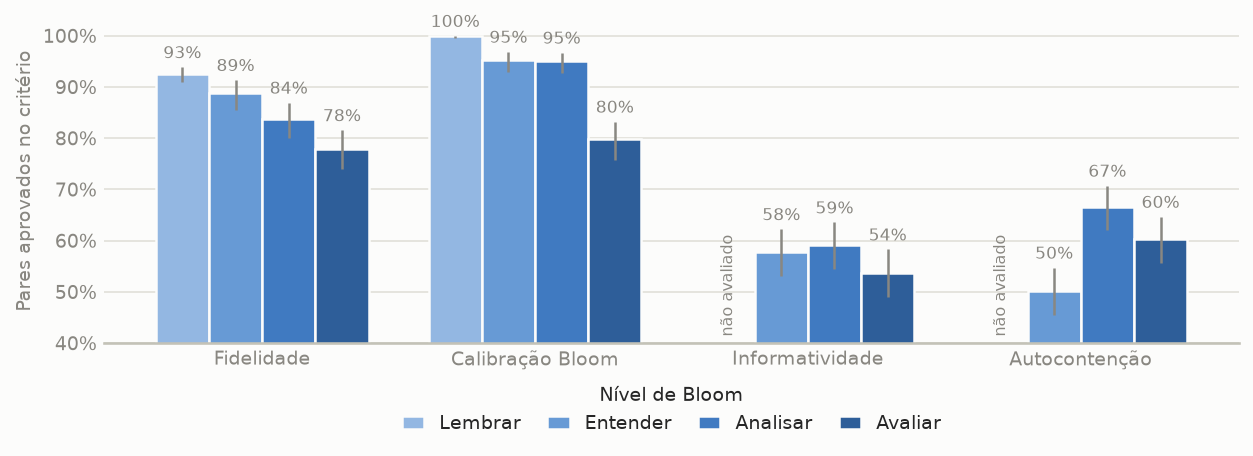

In [7]:
# Versao para artigo: sem titulo/subtitulo (a legenda vai no texto), achatada e
# com eixo iniciando em 40%.
#
# ATENCAO: com `ymin > 0` a altura da barra deixa de ser proporcional a taxa, e
# a diferenca entre barras parece maior do que e. O rotulo numerico em cada
# barra e o que mantem a figura honesta; nao remova. Se o corte do eixo for
# problema na revisao, o grafico de pontos (posicao, nao comprimento) admite
# eixo truncado sem distorcer.
FIG_DIR = REPO_ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

fig_artigo, ax_artigo = plot_approval(
    approval,
    ymin=0.40,
    figsize=(8.5, 3.2),
    label_size=8.0,
)

fig_path = FIG_DIR / f"aprovacao-criterio-bloom-{RUN_ID}.pdf"
fig_artigo.savefig(fig_path, facecolor=fig_artigo.get_facecolor(), bbox_inches="tight")
fig_artigo.savefig(fig_path.with_suffix(".png"), dpi=300, facecolor=fig_artigo.get_facecolor(), bbox_inches="tight")
print(f"figura salva em {fig_path.relative_to(REPO_ROOT)} (+ .png 300 dpi)")
plt.show()

## Pares aprovados e pares úteis: duas contas diferentes

A figura acima mostra a taxa **marginal** de cada critério. Daqui para frente
duas noções ficam separadas, porque medem coisas diferentes:

- **aprovado**: o par passou em *todos* os critérios avaliados no seu nível.
  É o que o pipeline grava como `is_valid`, e é a conta que dimensiona o funil
  do juiz.
- **útil**: o par é aprovado **e** está em um nível acima de `remember`. É a
  conta que interessa à pesquisa.

O recorte de `remember` não é arbitrário: o próprio juiz não avalia
`informativeness` nem `self_containedness` nesse nível (ver `qa/cep/judge.py`),
e informatividade é exatamente o critério que operacionaliza conhecimento
tácito. Um par `remember` aprovado passou por fidelidade e calibração, nunca
pelo crivo que a pesquisa exige. Chamá-lo de útil importaria uma garantia de
qualidade que nunca foi testada, e a seção de eco de metadados mostra na
prática o que entra por essa porta.

Como as reprovações são pouco correlacionadas entre critérios, a taxa conjunta
fica bem abaixo do pior critério isolado. Duas convenções mantidas aqui:

- critério não avaliado conta como ausência, nunca como reprovação;
- `aprovado` é recomputado a partir dos scores, então divergências em relação
  ao `is_valid` do pipeline ficam visíveis em vez de silenciosas.

In [8]:
# `remember` e recall factual por construcao e o juiz nem aplica
# informatividade nesse nivel, que e o criterio que operacionaliza conhecimento
# tacito. Aprovacao em `remember` mede fidelidade e calibracao, nao utilidade
# para a pesquisa.
NIVEIS_TACITOS = [level for level in BLOOM_ORDER if level != "remember"]


def approved_matrix(pairs: pd.DataFrame) -> pd.DataFrame:
    """Monta a matriz par x criterio com a decisao de aprovacao.

    Args:
        pairs: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Frame com uma coluna por criterio de `CRITERIA`: `1.0` aprovado, `0.0`
        reprovado e `NaN` quando o criterio nao foi avaliado (ausencia de
        avaliacao, nunca reprovacao).
    """
    columns: dict[str, pd.Series] = {}
    for criterion in CRITERIA:
        score, threshold = pairs[f"score_{criterion}"], pairs[f"thr_{criterion}"]
        missing = score.isna() | threshold.isna()
        columns[criterion] = (score >= threshold).astype(float).mask(missing)
    return pd.DataFrame(columns, index=pairs.index)


def with_usefulness(pairs: pd.DataFrame) -> pd.DataFrame:
    """Acrescenta as colunas de aprovacao e de utilidade ao frame de pares.

    Distingue duas nocoes:

    - `aprovado`: avaliado em ao menos um criterio e sem reprovacao em nenhum
      dos criterios avaliados; reproduz o `is_valid` do pipeline;
    - `util`: aprovado e em um nivel de `NIVEIS_TACITOS`, isto e, candidato a
      portar conhecimento tacito.

    Args:
        pairs: DataFrame de pares QA produzido por `load_cep_pairs`.

    Returns:
        Copia de `pairs` com `n_avaliados`, `n_reprovados`, `aprovado`,
        `candidato` e `util`.
    """
    approved = approved_matrix(pairs)
    out = pairs.copy()
    out["n_avaliados"] = approved.notna().sum(axis=1)
    out["n_reprovados"] = approved.eq(0.0).sum(axis=1)
    out["aprovado"] = (out["n_reprovados"] == 0) & (out["n_avaliados"] > 0)
    out["candidato"] = out["bloom_level"].isin(NIVEIS_TACITOS)
    out["util"] = out["aprovado"] & out["candidato"]
    return out


def joint_rates(pairs: pd.DataFrame) -> pd.DataFrame:
    """Agrega a taxa conjunta de aprovacao por nivel de Bloom.

    Mede o funil do juiz, entao usa `aprovado` (todos os criterios avaliados) e
    nao `util`: em `remember` a taxa continua definida.

    Args:
        pairs: Frame com a coluna `aprovado`, de `with_usefulness`.

    Returns:
        Frame indexado por `bloom_level` (na ordem de `BLOOM_ORDER`) com
        `pares`, `aprovados`, `taxa` e o IC 95% de Wilson (`ic_lo`, `ic_hi`).
    """
    rates = pairs.groupby("bloom_level", observed=True)["aprovado"].agg(
        pares="size", aprovados="sum"
    )
    rates["taxa"] = rates["aprovados"] / rates["pares"]
    rates[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(rates["aprovados"], rates["pares"])
    ]
    return rates.reindex(BLOOM_ORDER)


pairs = with_usefulness(df)
approved = approved_matrix(pairs)
joint = joint_rates(pairs)
display(joint)

print(f"aprovados (todos os criterios avaliados): {int(pairs['aprovado'].sum())}"
      f" / {len(pairs)} = {pairs['aprovado'].mean():.1%}")
print(f"is_valid do pipeline: {int(pairs['is_valid'].sum())} ({pairs['is_valid'].mean():.1%})")
print(f"divergencia aprovado vs is_valid: {int((pairs['aprovado'] != pairs['is_valid']).sum())} pares")

candidatos = int(pairs["candidato"].sum())
uteis = int(pairs["util"].sum())
print(f"\npares uteis (aprovados acima de remember): {uteis} / {candidatos} candidatos"
      f" = {uteis / candidatos:.1%}, ou {uteis / len(pairs):.1%} dos {len(pairs)} pares gerados")

# A divergencia e o par sem score de faithfulness: o juiz nao devolveu nota e o
# pipeline contou como reprovacao. Nao e reprovacao, e falha de avaliacao.
sem_nota = pairs[pairs["score_faithfulness"].isna()]
print(f"\npares sem score de faithfulness (falha do juiz): {len(sem_nota)}")
display(
    sem_nota.groupby(["bloom_level", "rejected_at"], observed=True)
    .size()
    .to_frame("pares")
)

,pares,aprovados,taxa,ic_lo,ic_hi
bloom_level,,,,,
remember,1335,1237,0.926592,0.911344,0.939392
understand,445,115,0.258427,0.219942,0.301047
analyze,445,146,0.328090,0.286099,0.373023
evaluate,445,93,0.208989,0.173782,0.249177


aprovados (todos os criterios avaliados): 1591 / 2670 = 59.6%
is_valid do pipeline: 1579 (59.1%)
divergencia aprovado vs is_valid: 12 pares

pares uteis (aprovados acima de remember): 354 / 1335 candidatos = 26.5%, ou 13.3% dos 2670 pares gerados

pares sem score de faithfulness (falha do juiz): 12


,,pares
bloom_level,rejected_at,
remember,cep_validation,12


In [9]:
# Quanto do funil cada critério sustenta, e quanto ele custa em pares.
def unique_blockers(pairs: pd.DataFrame, approved: pd.DataFrame) -> pd.DataFrame:
    """Conta, por nivel de Bloom, os pares reprovados em um unico criterio.

    E o ganho direto de pares uteis caso aquele criterio saisse do filtro: os
    demais criterios do par ja passaram.

    Args:
        pairs: Frame com `bloom_level` e `aprovado`.
        approved: Matriz de aprovacao de `approved_matrix`.

    Returns:
        Frame nivel x criterio com a contagem de gargalos unicos, mais a
        coluna `reprovados` (total de pares nao uteis do nivel).
    """
    counts: dict[str, pd.Series] = {}
    for criterion in CRITERIA:
        others = [c for c in CRITERIA if c != criterion]
        only = approved[criterion].eq(0.0) & approved[others].fillna(1.0).eq(1.0).all(axis=1)
        counts[criterion] = only.groupby(pairs["bloom_level"], observed=True).sum()
    table = pd.DataFrame(counts).reindex(BLOOM_ORDER).astype(int)
    table["reprovados"] = (
        (~pairs["aprovado"]).groupby(pairs["bloom_level"], observed=True).sum().reindex(BLOOM_ORDER)
    )
    return table


def drop_one_scenarios(pairs: pd.DataFrame, approved: pd.DataFrame) -> pd.DataFrame:
    """Pares uteis por nivel sob cenarios de remocao de um criterio.

    Args:
        pairs: Frame com `bloom_level`.
        approved: Matriz de aprovacao de `approved_matrix`.

    Returns:
        Frame nivel x cenario com a contagem de pares uteis e a linha `TOTAL`.
    """

    def yield_for(columns: list[str]) -> pd.Series:
        ok = approved[columns].fillna(1.0).eq(1.0).all(axis=1)
        grouped = ok.groupby(pairs["bloom_level"], observed=True).sum()
        return grouped.reindex(BLOOM_ORDER).astype(int)

    scenarios: dict[str, list[str]] = {"atual (4 criterios)": CRITERIA}
    for criterion in CRITERIA:
        label = CRITERION_LABELS[criterion].lower()
        scenarios[f"sem {label}"] = [c for c in CRITERIA if c != criterion]

    table = pd.DataFrame({name: yield_for(cols) for name, cols in scenarios.items()})
    table.loc["TOTAL"] = table.sum()
    return table


print("gargalo unico (pares reprovados so nesse criterio)")
display(unique_blockers(pairs, approved))

print("cenarios de remocao de criterio (pares uteis)")
cenarios = drop_one_scenarios(pairs, approved)
display(cenarios)
display((cenarios.loc["TOTAL"] / len(pairs)).to_frame("fracao_do_corpus").T.round(3))

gargalo unico (pares reprovados so nesse criterio)


,faithfulness,bloom_calibration,informativeness,self_containedness,reprovados
bloom_level,,,,,
remember,97,0,0,0,98
understand,10,2,80,114,330
analyze,27,12,91,67,299
evaluate,22,19,76,61,352


cenarios de remocao de criterio (pares uteis)


,atual (4 criterios),sem fidelidade,sem calibração bloom,sem informatividade,sem autocontenção
bloom_level,,,,,
remember,1237,1334,1237,1237,1237
understand,115,125,117,195,229
analyze,146,173,158,237,213
evaluate,93,115,112,169,154
TOTAL,1591,1747,1624,1838,1833


,atual (4 criterios),sem fidelidade,sem calibração bloom,sem informatividade,sem autocontenção
fracao_do_corpus,0.596,0.654,0.608,0.688,0.687


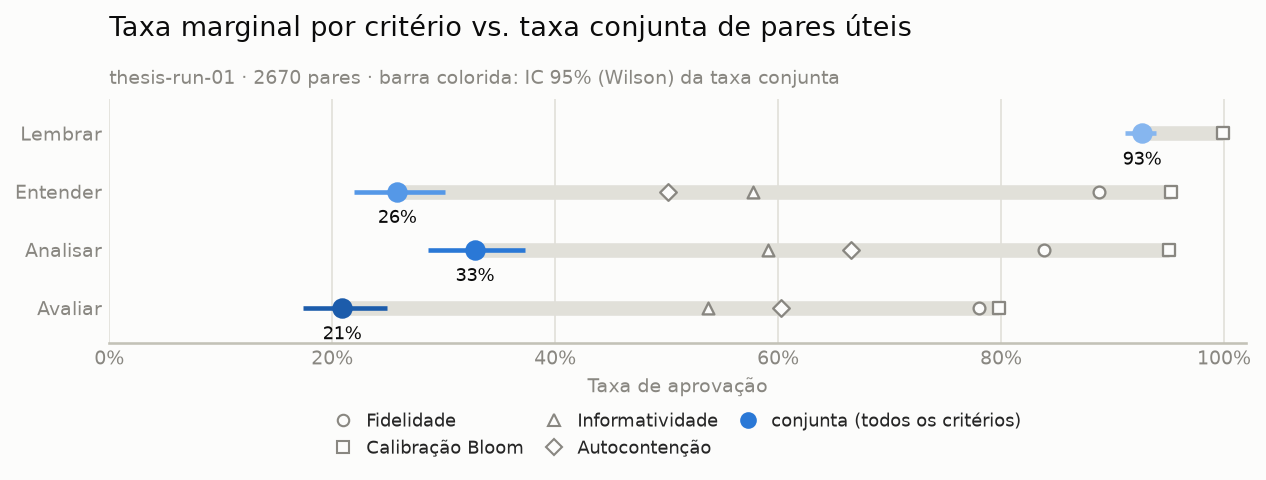

In [10]:
from matplotlib.lines import Line2D

# Marcadores abertos = taxa marginal de cada criterio; ponto cheio = taxa
# conjunta. A barra cinza liga os dois extremos, entao o vao entre "pior
# criterio" e "par utilizavel" e a propria leitura do grafico.
CRITERION_MARKERS = {
    "faithfulness": "o",
    "bloom_calibration": "s",
    "informativeness": "^",
    "self_containedness": "D",
}


def plot_marginal_vs_joint(
    marginal: pd.DataFrame,
    joint: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (8.6, 3.6),
    title: str | None = None,
    subtitle: str | None = None,
) -> tuple[Figure, Axes]:
    """Contrasta as taxas marginais por criterio com a taxa conjunta.

    Args:
        marginal: Frame de `approval_rates`, indexado por
            (`criterion`, `bloom_level`).
        joint: Frame de `joint_rates`, indexado por `bloom_level`.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite.
        subtitle: Linha de procedencia sob o titulo. `None` omite.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    for index, level in enumerate(BLOOM_ORDER):
        y = len(BLOOM_ORDER) - 1 - index
        taxa_conjunta = joint.loc[level, "taxa"]
        marginais = [
            marginal.loc[(criterion, level), "taxa"]
            for criterion in CRITERIA
            if pd.notna(marginal.loc[(criterion, level), "taxa"])
        ]
        extremos = [*marginais, taxa_conjunta]
        ax.hlines(y, min(extremos), max(extremos), color=GRID, linewidth=7, zorder=1)

        for criterion in CRITERIA:
            taxa = marginal.loc[(criterion, level), "taxa"]
            if pd.isna(taxa):
                continue
            ax.scatter(
                taxa, y, marker=CRITERION_MARKERS[criterion], s=32, facecolor=SURFACE,
                edgecolor=MUTED, linewidth=1.1, zorder=2,
            )

        ax.scatter(taxa_conjunta, y, s=78, color=BLOOM_RAMP[index], zorder=3)
        ax.annotate(
            f"{taxa_conjunta:.0%}", (taxa_conjunta, y), textcoords="offset points",
            xytext=(0, -15), ha="center", fontsize=8.5, color=INK,
        )
        ax.hlines(
            y, joint.loc[level, "ic_lo"], joint.loc[level, "ic_hi"],
            color=BLOOM_RAMP[index], linewidth=2.2, zorder=4,
        )

    ax.set_yticks(range(len(BLOOM_ORDER)))
    ax.set_yticklabels([BLOOM_LABELS[b] for b in reversed(BLOOM_ORDER)])
    ax.set_ylim(-0.6, len(BLOOM_ORDER) - 0.4)
    ax.set_xlim(0, 1.02)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_xlabel("Taxa de aprovação", color=MUTED, fontsize=9)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=30)
    if subtitle:
        ax.text(0, 1.06, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    handles = [
        Line2D(
            [], [], marker=CRITERION_MARKERS[c], linestyle="none", markersize=5.5,
            markerfacecolor=SURFACE, markeredgecolor=MUTED, label=CRITERION_LABELS[c],
        )
        for c in CRITERIA
    ]
    handles.append(
        Line2D([], [], marker="o", linestyle="none", markersize=7, color=BLOOM_RAMP[2],
               label="conjunta (todos os critérios)")
    )
    ax.legend(
        handles=handles, frameon=False, ncol=3, loc="upper center",
        bbox_to_anchor=(0.5, -0.22), fontsize=8.5, columnspacing=1.2, handlelength=1.0,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig_conjunta, _ = plot_marginal_vs_joint(
    approval,
    joint,
    title="Taxa marginal por critério vs. taxa conjunta de pares úteis",
    subtitle=f"{RUN_ID} · {len(pairs)} pares · barra colorida: IC 95% (Wilson) da taxa conjunta",
)
plt.show()

## Decomposição aditiva: o que decidiu o destino de cada par

A figura de aprovação por critério é **marginal**: cada célula é calculada de
forma independente, sobre todos os pares com nota naquele critério. Ela não
mistura critérios (um par reprovado em informatividade continua contando como
aprovado em calibração, e o juiz avalia os quatro critérios de todo par, sem
curto-circuito), mas ela também não diz qual critério *decidiu* a reprovação.

A diferença é grande para `bloom_calibration`: ela reprova 134 pares no run,
e é a única razão da reprovação em apenas 33. Nos outros 101 o par já estava
reprovado por informatividade ou autocontenção. Ler a barra de calibração como
"pares que a calibração derrubou" superestima o filtro em 4x.

A decomposição abaixo atribui cada par a **um único** segmento, então as
colunas somam exatamente aos pares gerados no nível:

- `aprovado`: passou em todos os critérios aplicáveis ao nível;
- `só <critério>`: reprovou naquele critério e passou em todos os outros, ou
  seja, aquele critério foi o fator decisivo;
- `2 ou mais critérios`: reprovou em mais de um, nenhum foi decisivo isolado;
- `sem avaliação (falha do juiz)`: o juiz não devolveu nota de um critério
  aplicável, e o pipeline contou como reprovação. Não é reprovação, é ausência
  de avaliação, e é o que separa os 1591 pares úteis dos 1579 `is_valid`.

Os critérios aplicáveis a cada nível são inferidos dos próprios artefatos (um
critério é aplicável se há ao menos uma nota dele no nível), e não codificados
aqui, para a figura acompanhar mudanças na configuração do juiz.

Esta figura é sobre **aprovação**, não sobre utilidade: o segmento `aprovado` de
`remember` são 1225 pares que passaram por fidelidade e calibração e nunca por
informatividade. Eles fecham o `is_valid` do pipeline, e é por isso que
aparecem aqui, mas não contam como pares úteis.

In [11]:
SEGMENT_ORDER = ["aprovado", *CRITERIA, "multi", "sem_avaliacao"]
SEGMENT_LABELS = {
    "aprovado": "aprovado",
    "faithfulness": f"só {CRITERION_LABELS['faithfulness']}",
    "bloom_calibration": f"só {CRITERION_LABELS['bloom_calibration']}",
    "informativeness": f"só {CRITERION_LABELS['informativeness']}",
    "self_containedness": f"só {CRITERION_LABELS['self_containedness']}",
    "multi": "2 ou mais critérios",
    "sem_avaliacao": "sem avaliação (falha do juiz)",
}


def applicable_criteria(pairs: pd.DataFrame) -> dict[str, list[str]]:
    """Descobre, por nivel de Bloom, quais criterios o juiz de fato avaliou.

    Lido dos artefatos em vez de codificado: se a configuracao do juiz mudar
    (hoje `informativeness` e `self_containedness` nao se aplicam a
    `remember`), a decomposicao acompanha.

    Args:
        pairs: DataFrame de pares QA com as colunas `score_*`.

    Returns:
        Mapa de nivel de Bloom para a lista de criterios com ao menos uma nota.
    """
    mapa: dict[str, list[str]] = {}
    for level in BLOOM_ORDER:
        nivel = pairs[pairs["bloom_level"] == level]
        mapa[level] = [c for c in CRITERIA if nivel[f"score_{c}"].notna().any()]
    return mapa


def rejection_reason(
    pairs: pd.DataFrame,
    approved: pd.DataFrame,
    aplicaveis: dict[str, list[str]],
) -> pd.Series:
    """Atribui a cada par o unico motivo que decidiu seu destino.

    Um par reprovado em exatamente um criterio recebe o nome desse criterio: e
    o fator decisivo, porque passou em todos os outros. Reprovado em mais de um
    vira `multi`, e nenhum criterio pode ser responsabilizado isoladamente.

    Args:
        pairs: DataFrame de pares QA com `bloom_level`.
        approved: Matriz de aprovacao de `approved_matrix`.
        aplicaveis: Mapa de `applicable_criteria`.

    Returns:
        Serie com um rotulo de `SEGMENT_ORDER` por par.
    """
    motivo = pd.Series(index=pairs.index, dtype="object", name="motivo")
    for level, esperados in aplicaveis.items():
        no_nivel = pairs["bloom_level"] == level
        bloco = approved.loc[no_nivel, esperados]
        falhas = bloco.eq(0.0)
        n_falhas = falhas.sum(axis=1)

        rotulo = pd.Series("aprovado", index=bloco.index)
        rotulo[(n_falhas == 0) & bloco.isna().any(axis=1)] = "sem_avaliacao"
        uma_falha = n_falhas == 1
        rotulo[uma_falha] = falhas.loc[uma_falha].idxmax(axis=1)
        rotulo[n_falhas > 1] = "multi"
        motivo[no_nivel] = rotulo
    return motivo


def rejection_decomposition(pairs: pd.DataFrame) -> pd.DataFrame:
    """Tabula os motivos por nivel de Bloom, na ordem de `SEGMENT_ORDER`.

    Args:
        pairs: DataFrame com `bloom_level` e `motivo`.

    Returns:
        Frame nivel x segmento com contagens; as linhas somam aos pares
        gerados no nivel.
    """
    table = pd.crosstab(pairs["bloom_level"], pairs["motivo"])
    table = table.reindex(index=BLOOM_ORDER, columns=SEGMENT_ORDER, fill_value=0)
    return table.rename(columns=SEGMENT_LABELS)


pairs["motivo"] = rejection_reason(pairs, approved, applicable_criteria(pairs))
decomposicao = rejection_decomposition(pairs)
decomposicao["total"] = decomposicao.sum(axis=1)
display(decomposicao)

print("em % dos pares gerados no nivel")
share = decomposicao.drop(columns="total")
display((share.div(decomposicao["total"], axis=0) * 100).round(1))

# A decomposicao e fechada: o segmento `aprovado` tem que reproduzir o
# is_valid do pipeline, e cada linha somar aos pares gerados no nivel.
aprovados = int(decomposicao["aprovado"].sum())
print(f"\naprovados na decomposicao: {aprovados} | is_valid do pipeline: {int(pairs['is_valid'].sum())}")
print(f"soma dos segmentos: {int(share.to_numpy().sum())} | pares: {len(pairs)}")

motivo,aprovado,só Fidelidade,só Calibração Bloom,só Informatividade,só Autocontenção,2 ou mais critérios,sem avaliação (falha do juiz),total
bloom_level,,,,,,,,
remember,1225,97,0,0,0,1,12,1335
understand,115,10,2,80,114,124,0,445
analyze,146,27,12,91,67,102,0,445
evaluate,93,22,19,76,61,174,0,445


em % dos pares gerados no nivel


motivo,aprovado,só Fidelidade,só Calibração Bloom,só Informatividade,só Autocontenção,2 ou mais critérios,sem avaliação (falha do juiz)
bloom_level,,,,,,,
remember,91.8,7.3,0.0,0.0,0.0,0.1,0.9
understand,25.8,2.2,0.4,18.0,25.6,27.9,0.0
analyze,32.8,6.1,2.7,20.4,15.1,22.9,0.0
evaluate,20.9,4.9,4.3,17.1,13.7,39.1,0.0



aprovados na decomposicao: 1579 | is_valid do pipeline: 1579
soma dos segmentos: 2670 | pares: 2670


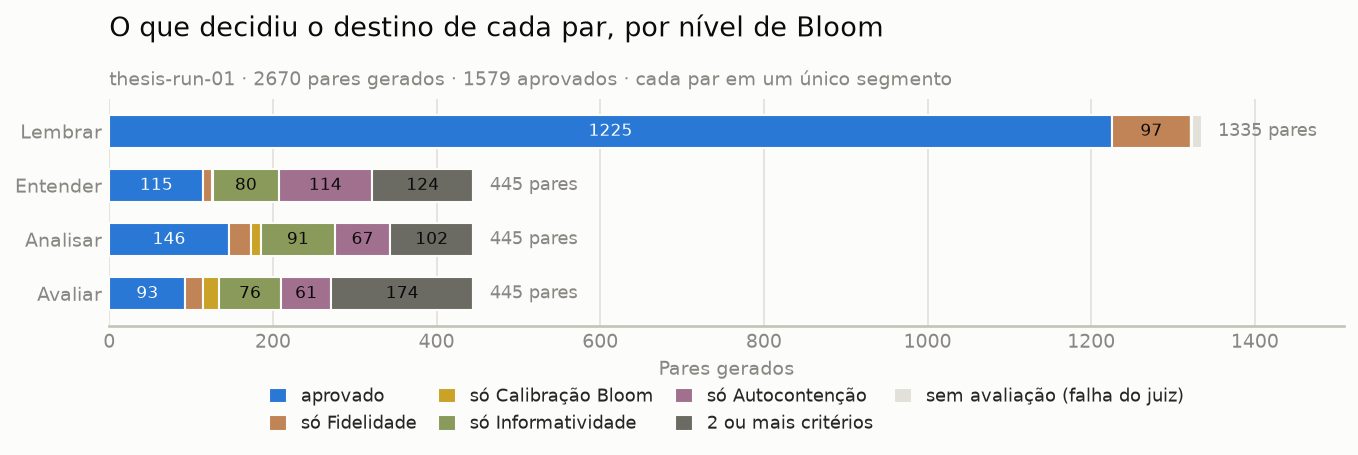

In [12]:
# Azul para o aprovado (mesma familia da rampa de Bloom) e tons quentes para os
# motivos de reprovacao: a distincao aprovado/reprovado sobrevive em escala de
# cinza, e cada motivo tem matiz propria em vez de depender da ordem da pilha.
SEGMENT_COLORS = {
    "aprovado": BLOOM_RAMP[2],
    "faithfulness": "#c08457",
    "bloom_calibration": "#c9a227",
    "informativeness": "#8a9a5b",
    "self_containedness": "#a2708f",
    "multi": "#6b6a63",
    "sem_avaliacao": GRID,
}


def plot_rejection_decomposition(
    decomposicao: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (9.2, 3.4),
    title: str | None = None,
    subtitle: str | None = None,
    normalize: bool = False,
    min_share: float = 0.028,
) -> tuple[Figure, Axes]:
    """Desenha a decomposicao aditiva dos pares gerados, por nivel de Bloom.

    Barras empilhadas, cada par em um unico segmento. Em contagem absoluta o
    comprimento total e o numero de pares gerados no nivel (3 `remember` por
    chunk contra 1 dos demais), o que espreme os niveis superiores; normalizado,
    os quatro niveis ficam comparaveis e o total vai para a anotacao a direita.
    Os rotulos internos sao sempre a contagem, nos dois modos.

    Args:
        decomposicao: Frame de `rejection_decomposition`, com ou sem a coluna
            `total` (ignorada).
        figsize: Largura e altura da figura em polegadas.
        title: Titulo do eixo. `None` omite (caso de figura para artigo).
        subtitle: Linha de procedencia sob o titulo. `None` omite.
        normalize: Se `True`, cada barra vira 1,0 e o eixo passa a proporcao.
        min_share: Largura minima do segmento, como fracao da extensao do eixo,
            para receber rotulo interno; os menores ficam legiveis so na tabela.

    Returns:
        A figura e o eixo, para o chamador salvar ou ajustar.
    """
    contagens = decomposicao.drop(columns="total", errors="ignore")
    totais = contagens.sum(axis=1)
    dados = contagens.div(totais, axis=0) if normalize else contagens
    limite = 1.0 if normalize else float(totais.max())
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    posicoes = [len(BLOOM_ORDER) - 1 - i for i in range(len(BLOOM_ORDER))]
    esquerda = pd.Series(0.0, index=dados.index)
    for chave in SEGMENT_ORDER:
        coluna = SEGMENT_LABELS[chave]
        valores = dados[coluna]
        ax.barh(
            posicoes, valores, left=esquerda, height=0.62,
            color=SEGMENT_COLORS[chave], edgecolor=SURFACE, linewidth=1.0,
            label=coluna, zorder=2,
        )
        for y, base, valor, contagem in zip(posicoes, esquerda, valores, contagens[coluna]):
            if valor / limite >= min_share:
                ax.text(
                    base + valor / 2, y, f"{int(contagem)}", ha="center", va="center",
                    fontsize=8, color=SURFACE if chave == "aprovado" else INK, zorder=3,
                )
        esquerda = esquerda + valores

    for y, fim, total in zip(posicoes, esquerda, totais):
        rotulo = f"n = {int(total)}" if normalize else f"{int(total)} pares"
        ax.text(fim + limite * 0.015, y, rotulo, va="center", fontsize=8.5, color=MUTED)

    ax.set_yticks(posicoes)
    ax.set_yticklabels([BLOOM_LABELS[b] for b in BLOOM_ORDER])
    ax.set_ylim(-0.6, len(BLOOM_ORDER) - 0.4)
    ax.set_xlim(0, limite * 1.13)
    ax.xaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    if normalize:
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_xlabel(
        "Proporção dos pares gerados" if normalize else "Pares gerados",
        color=MUTED, fontsize=9,
    )
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for side, spine in ax.spines.items():
        spine.set_visible(side == "bottom")
        spine.set_color(AXIS)

    if title:
        ax.set_title(title, loc="left", fontsize=13, color=INK, pad=30)
    if subtitle:
        ax.text(0, 1.06, subtitle, transform=ax.transAxes, fontsize=9, color=MUTED)

    ax.legend(
        frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2),
        fontsize=8.5, columnspacing=1.2, handlelength=1.0, handleheight=1.0,
    )
    sns.despine(ax=ax, left=True)
    fig.tight_layout()
    return fig, ax


fig_decomposicao, _ = plot_rejection_decomposition(
    decomposicao,
    title="O que decidiu o destino de cada par, por nível de Bloom",
    subtitle=(
        f"{RUN_ID} · {len(pairs)} pares gerados · {int(pairs['is_valid'].sum())} aprovados"
        " · cada par em um único segmento"
    ),
)
plt.show()

## Rendimento por chunk: tamanho, taxa e densidade

O gerador produz uma escada de Bloom fixa por chunk (`bloom_distribution`
travado em 3/1/1/1), independente do tamanho do chunk. Dos 6 pares, 3 são
candidatos a par útil (os níveis acima de `remember`), também sem relação com
o tamanho. Isso separa duas perguntas:

- **taxa de aproveitamento**: dos 3 candidatos do chunk, quantos são úteis;
- **densidade**: quantos pares úteis o chunk rende por caractere de contexto.

Com orçamento fixo, o número de *candidatos* por caractere é inversamente
proporcional ao tamanho por construção. A densidade de pares *úteis* não
herda isso de forma limpa, porque a taxa de aproveitamento se move na direção
oposta: chunk curto gera candidatos baratos que reprovam. O efeito líquido é o
que decide se transcrições longas estão sendo exploradas na mesma proporção
que as curtas.

In [13]:
# Faixas de tamanho de chunk: a janela do chunker termina em 4000 caracteres,
# e as faixas finas no topo separam chunks "cheios" dos parciais.
CHUNK_BINS = [0, 500, 1000, 2000, 3000, 3500, 3900, 4001]
CHUNK_LABELS = ["<0,5k", "0,5-1k", "1-2k", "2-3k", "3-3,5k", "3,5-3,9k", "3,9-4k"]


def chunk_table(pairs: pd.DataFrame) -> pd.DataFrame:
    """Agrega os pares por chunk, com tamanho do contexto e pares uteis.

    Args:
        pairs: Frame com `chunk_id`, `context_chars`, `candidato` e `util`.

    Returns:
        Frame indexado por `chunk_id` com `source_gdrive_id`, `chars`,
        `gerados`, `candidatos`, `uteis`, `taxa` (sobre os candidatos) e a
        `faixa` de tamanho.

    Raises:
        ValueError: Se `context_chars` variar dentro de um mesmo `chunk_id`,
            o que invalidaria `chars` como tamanho do chunk.
    """
    if (pairs.groupby("chunk_id", observed=True)["context_chars"].nunique() > 1).any():
        raise ValueError("context_chars varia dentro de um chunk_id")

    table = pairs.groupby("chunk_id", observed=True).agg(
        source_gdrive_id=("source_gdrive_id", "first"),
        chars=("context_chars", "max"),
        gerados=("util", "size"),
        candidatos=("candidato", "sum"),
        uteis=("util", "sum"),
    )
    table["taxa"] = table["uteis"] / table["candidatos"]
    table["faixa"] = pd.cut(table["chars"], CHUNK_BINS, labels=CHUNK_LABELS, right=False)
    return table


chunks = chunk_table(pairs)
print(f"{len(chunks)} chunks · {int(chunks['gerados'].sum())} pares gerados"
      f" · {int(chunks['candidatos'].sum())} candidatos acima de remember")
display(chunks["chars"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame("chars"))

distribuicao = (
    chunks["uteis"].value_counts().reindex(range(4), fill_value=0).sort_index().to_frame("chunks")
)
distribuicao["fracao"] = distribuicao["chunks"] / len(chunks)
distribuicao.index.name = "uteis"
print("pares uteis por chunk (de 3 candidatos)")
display(distribuicao)

print(f"chunks sem nenhum par util: {int((chunks['uteis'] == 0).sum())} de {len(chunks)}")
print(f"chunks com os 3 candidatos uteis: {int((chunks['uteis'] == 3).sum())}")
print(f"media de pares uteis por chunk: {chunks['uteis'].mean():.2f} de 3")

# Para referencia, quantos pares aprovados cada chunk rende em cada nivel: em
# `remember` a base factual passa quase sempre, e e ela que sustenta o total do
# pipeline sem contribuir com pares uteis.
aprovados_por_nivel = (
    pairs.pivot_table(
        index="chunk_id", columns="bloom_level", values="aprovado", aggfunc="sum", observed=True
    )
    .reindex(columns=BLOOM_ORDER)
    .fillna(0)
    .astype(int)
)
display(aprovados_por_nivel.apply(lambda column: column.value_counts()).fillna(0).astype(int))

445 chunks · 2670 pares gerados · 1335 candidatos acima de remember


,chars
count,445.000000
mean,2778.975281
std,1300.186618
min,24.000000
5%,345.600000
25%,1611.000000
50%,3421.000000
75%,3930.000000
95%,3991.000000
max,4000.000000


pares uteis por chunk (de 3 candidatos)


,chunks,fracao
uteis,,
0,203,0.456180
1,151,0.339326
2,70,0.157303
3,21,0.047191


chunks sem nenhum par util: 203 de 445
chunks com os 3 candidatos uteis: 21
media de pares uteis por chunk: 0.80 de 3


bloom_level,remember,understand,analyze,evaluate
0,4,330,299,352
1,5,115,146,93
2,76,0,0,0
3,360,0,0,0


In [14]:
def band_yield(chunks: pd.DataFrame) -> pd.DataFrame:
    """Taxa e densidade de pares uteis por faixa de tamanho de chunk.

    Args:
        chunks: Frame de `chunk_table`.

    Returns:
        Frame indexado por `faixa` com `chunks`, `chars`, `candidatos`,
        `uteis`, `taxa` (sobre os candidatos) e IC 95% de Wilson,
        `uteis_por_1k` (pares uteis por mil caracteres de contexto) e
        `chars_por_util`.
    """
    table = chunks.groupby("faixa", observed=True).agg(
        chunks=("uteis", "size"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    table["taxa"] = table["uteis"] / table["candidatos"]
    table[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(table["uteis"], table["candidatos"])
    ]
    table["uteis_por_1k"] = table["uteis"] / table["chars"] * 1000
    table["chars_por_util"] = table["chars"] / table["uteis"]
    return table


def spearman(left: pd.Series, right: pd.Series) -> float:
    """Correlacao de Spearman como Pearson sobre os postos.

    Calculada assim para nao exigir `scipy`, que nao esta no extra `analysis`.

    Args:
        left: Primeira serie.
        right: Segunda serie, alinhada por indice.

    Returns:
        Coeficiente entre -1 e 1.
    """
    return float(left.rank().corr(right.rank()))


def short_vs_long(pairs: pd.DataFrame, cutoff: int = 1000) -> pd.DataFrame:
    """Compara a taxa de aprovacao em chunks curtos e longos, por nivel.

    Usa `aprovado` para a taxa continuar definida em `remember`, que serve de
    controle: se o encurtamento do chunk derruba os niveis superiores e nao o
    recall factual, o efeito e sobre o raciocinio, nao sobre a extracao.

    Args:
        pairs: Frame com `context_chars`, `bloom_level` e `aprovado`.
        cutoff: Fronteira em caracteres entre chunk curto e longo.

    Returns:
        Frame indexado por (`bloom_level`, `faixa`) com `pares`, `aprovados`,
        `taxa` e o IC 95% de Wilson.
    """
    curto = pairs["context_chars"] < cutoff
    faixa = pd.Series(
        pd.Categorical(
            curto.map({True: f"<{cutoff}", False: f">={cutoff}"}),
            [f"<{cutoff}", f">={cutoff}"],
            ordered=True,
        ),
        index=pairs.index,
        name="faixa",
    )
    grouped = pairs.groupby([pairs["bloom_level"], faixa], observed=True)["aprovado"]
    table = grouped.agg(pares="size", aprovados="sum")
    table["taxa"] = table["aprovados"] / table["pares"]
    table[["ic_lo", "ic_hi"]] = [
        wilson_interval(int(k), int(n)) for k, n in zip(table["aprovados"], table["pares"])
    ]
    return table.reindex(BLOOM_ORDER, level="bloom_level")


faixas = band_yield(chunks)
print("taxa e densidade por faixa de tamanho de chunk")
display(faixas)

print("chunk curto vs. longo: taxa de aprovacao por nivel de Bloom")
display(short_vs_long(pairs))

print(f"Spearman tamanho do chunk x taxa de uteis do chunk: {spearman(chunks['chars'], chunks['taxa']):+.3f}")
for level in BLOOM_ORDER:
    nivel = pairs[pairs["bloom_level"] == level]
    agg = nivel.groupby("chunk_id", observed=True).agg(
        chars=("context_chars", "max"), taxa=("aprovado", "mean")
    )
    print(f"  {level:11s} (aprovacao) {spearman(agg['chars'], agg['taxa']):+.3f}")

taxa e densidade por faixa de tamanho de chunk


,chunks,chars,candidatos,uteis,taxa,ic_lo,ic_hi,uteis_por_1k,chars_por_util
faixa,,,,,,,,,
"<0,5k",30,8256,90,7,0.077778,0.038184,0.151940,0.847868,1179.428571
"0,5-1k",35,24598,105,20,0.190476,0.126824,0.275978,0.813074,1229.900000
1-2k,75,111845,225,60,0.266667,0.213154,0.328013,0.536457,1864.083333
2-3k,51,130967,153,43,0.281046,0.215855,0.356963,0.328327,3045.744186
"3-3,5k",39,128356,117,39,0.333333,0.254414,0.422849,0.303842,3291.179487
"3,5-3,9k",87,324958,261,81,0.310345,0.257309,0.368882,0.249263,4011.827160
"3,9-4k",128,507664,384,104,0.270833,0.228817,0.317389,0.204860,4881.384615


chunk curto vs. longo: taxa de aprovacao por nivel de Bloom


pares  aprovados      taxa     ic_lo     ic_hi
bloom_level faixa                                                 
remember    <1000     195        183  0.938462  0.895530  0.964451
            >=1000   1140       1054  0.924561  0.907764  0.938507
understand  <1000      65         12  0.184615  0.108888  0.295542
            >=1000    380        103  0.271053  0.228816  0.317872
analyze     <1000      65          8  0.123077  0.063704  0.224517
            >=1000    380        138  0.363158  0.316397  0.412658
evaluate    <1000      65          7  0.107692  0.053154  0.206015
            >=1000    380         86  0.226316  0.187103  0.271006

Spearman tamanho do chunk x taxa de uteis do chunk: +0.122
  remember    (aprovacao) -0.079
  understand  (aprovacao) +0.044
  analyze     (aprovacao) +0.110
  evaluate    (aprovacao) +0.082


In [15]:
def per_document_yield(chunks: pd.DataFrame, quantis: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Rendimento por transcricao e por quintil de tamanho total.

    Args:
        chunks: Frame de `chunk_table`.
        quantis: Numero de faixas de tamanho total de transcricao.

    Returns:
        Par (`por_doc`, `por_quantil`): o primeiro indexado por
        `source_gdrive_id` com `n_chunks`, `chars`, `candidatos`, `uteis`,
        `taxa` e `uteis_por_1k`; o segundo agregado por faixa de tamanho.
    """
    por_doc = chunks.groupby("source_gdrive_id").agg(
        n_chunks=("chars", "size"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    por_doc["taxa"] = por_doc["uteis"] / por_doc["candidatos"]
    por_doc["uteis_por_1k"] = por_doc["uteis"] / por_doc["chars"] * 1000

    faixa = pd.qcut(por_doc["chars"], quantis, labels=[f"Q{i + 1}" for i in range(quantis)])
    por_quantil = por_doc.groupby(faixa, observed=True).agg(
        docs=("chars", "size"),
        chars_medianos=("chars", "median"),
        chunks_medianos=("n_chunks", "median"),
        chars=("chars", "sum"),
        candidatos=("candidatos", "sum"),
        uteis=("uteis", "sum"),
    )
    por_quantil["taxa"] = por_quantil["uteis"] / por_quantil["candidatos"]
    por_quantil["uteis_por_1k"] = por_quantil["uteis"] / por_quantil["chars"] * 1000
    return por_doc, por_quantil


por_doc, por_quantil = per_document_yield(chunks)
print("rendimento por quintil de tamanho da transcricao (Q1 = menores)")
display(por_quantil.drop(columns="chars"))

print(f"Spearman chars totais x uteis por 1k: {spearman(por_doc['chars'], por_doc['uteis_por_1k']):+.3f}")
print(f"Spearman chars totais x taxa de uteis: {spearman(por_doc['chars'], por_doc['taxa']):+.3f}")

maior = por_doc.sort_values("chars").iloc[-1]
print(
    f"\nmaior transcricao: {int(maior['chars'])} chars em {int(maior['n_chunks'])} chunks"
    f" -> {int(maior['uteis'])} uteis ({maior['uteis_por_1k']:.2f} por 1k)"
)

# Chunks-resto: o chunker nao tem piso, entao sobras minusculas ainda recebem a
# escada completa de 6 pares.
restos = chunks[chunks["chars"] < 500].sort_values("chars")
print(f"\nchunks abaixo de 500 chars: {len(restos)} -> {int(restos['gerados'].sum())} pares"
      f" gerados, {int(restos['candidatos'].sum())} candidatos, {int(restos['uteis'].sum())} uteis")
display(restos.head(10))

rendimento por quintil de tamanho da transcricao (Q1 = menores)


,docs,chars_medianos,chunks_medianos,candidatos,uteis,taxa,uteis_por_1k
chars,,,,,,,
Q1,43,502.0,1.0,129,15,0.116279,0.736594
Q2,43,1321.0,1.0,129,29,0.224806,0.501192
Q3,42,2950.5,1.0,126,28,0.222222,0.235786
Q4,43,5452.0,2.0,264,73,0.276515,0.288652
Q5,43,10472.0,3.0,687,209,0.304221,0.265644


Spearman chars totais x uteis por 1k: +0.186
Spearman chars totais x taxa de uteis: +0.352

maior transcricao: 134971 chars em 39 chunks -> 41 uteis (0.30 por 1k)

chunks abaixo de 500 chars: 30 -> 180 pares gerados, 90 candidatos, 7 uteis


,source_gdrive_id,chars,gerados,candidatos,uteis,taxa,faixa
chunk_id,,,,,,,
3f7ca42c5bcce6c4,1rAwXptR47e-_nUIdcbtbI8N1qUOu184A,24,6,3,0,0.000000,"<0,5k"
38b8b0cebefb8e88,1Iq-BExRG5X7lXmBqgLxLcAeUVmUPciHP,59,6,3,0,0.000000,"<0,5k"
f610957c458f6796,1UedB859RjifjCbCKwhaa5mHDYhxMnptJ,60,6,3,0,0.000000,"<0,5k"
e97d4e4419fbcbb5,1PAeQJbpnL4U4xCZy2cAKRIz6ZWkyFmp_,137,6,3,0,0.000000,"<0,5k"
2e533519cd07fa64,1-ptIECorsTNLKe2pVKB5hap9IWKI6VM8,207,6,3,0,0.000000,"<0,5k"
88c52b9fd9a38688,1R6rBdQ3q8mQTeQ8ooYi-NC128Ef5-2GR,215,6,3,1,0.333333,"<0,5k"
e9a2a69cf52b0a0f,1LYnrI4Bv8p-0xBMYoZnj3B17Li_1LZPa,215,6,3,0,0.000000,"<0,5k"
71274b9ab96cdaed,16On1PetEM_2I-LZvKcyvsA775cLZiaWF,216,6,3,0,0.000000,"<0,5k"
3fee64c904844db9,1eWaz7PVbtknqlxeZE5Z-Zbhi494iltNC,225,6,3,0,0.000000,"<0,5k"


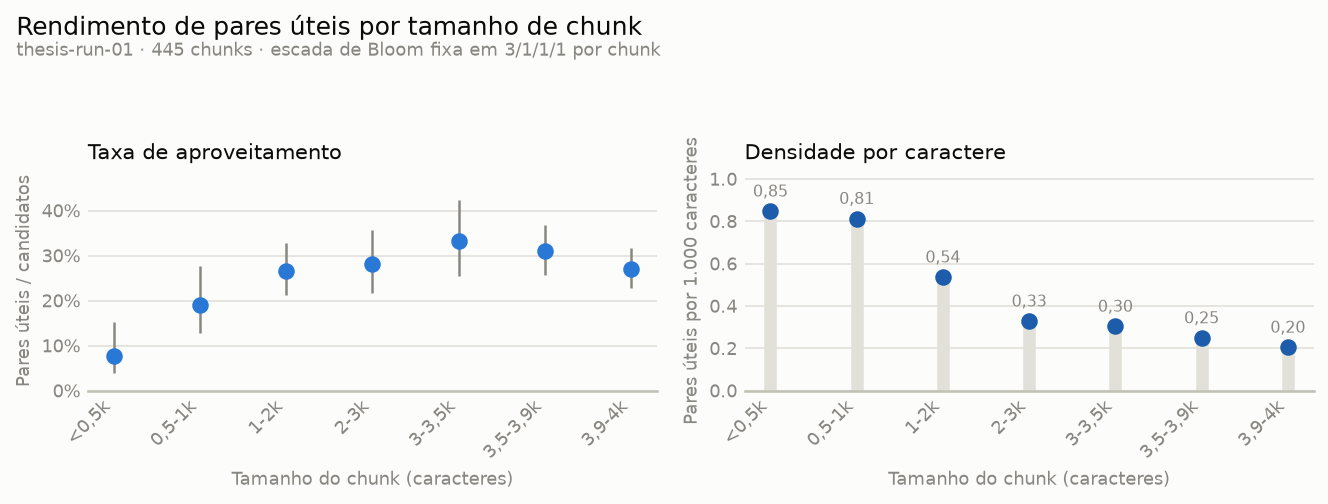

In [16]:
def plot_chunk_yield(
    faixas: pd.DataFrame,
    *,
    figsize: tuple[float, float] = (9.0, 3.4),
    title: str | None = None,
    subtitle: str | None = None,
) -> tuple[Figure, tuple[Axes, Axes]]:
    """Desenha taxa e densidade de pares uteis por faixa de tamanho de chunk.

    Os dois paineis usam base em zero: a taxa e uma proporcao, e a densidade
    so e comparavel entre faixas se o comprimento do traco for proporcional ao
    valor.

    Args:
        faixas: Frame de `band_yield`.
        figsize: Largura e altura da figura em polegadas.
        title: Titulo da figura. `None` omite.
        subtitle: Linha de procedencia sob o titulo. `None` omite.

    Returns:
        A figura e o par de eixos (taxa, densidade).
    """
    fig, (ax_taxa, ax_dens) = plt.subplots(1, 2, figsize=figsize, dpi=150)
    fig.patch.set_facecolor(SURFACE)
    posicoes = range(len(faixas))

    for ax in (ax_taxa, ax_dens):
        ax.set_facecolor(SURFACE)
        ax.set_xticks(list(posicoes))
        ax.set_xticklabels(faixas.index, rotation=45, ha="right")
        ax.yaxis.grid(True, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.tick_params(colors=MUTED, labelsize=8.5, length=0)
        for side, spine in ax.spines.items():
            spine.set_visible(side == "bottom")
            spine.set_color(AXIS)
        ax.set_xlabel("Tamanho do chunk (caracteres)", color=MUTED, fontsize=8.5)

    ax_taxa.vlines(list(posicoes), faixas["ic_lo"], faixas["ic_hi"], color=MUTED, linewidth=1.2)
    ax_taxa.scatter(list(posicoes), faixas["taxa"], s=48, color=BLOOM_RAMP[2], zorder=3)
    # Base em zero (a taxa e proporcao), topo ajustado aos dados: com a
    # definicao estrita de util as taxas ficam longe de 100% e um eixo cheio
    # esconderia as diferencas entre faixas.
    ax_taxa.set_ylim(0, min(1.0, max(0.4, float(faixas["ic_hi"].max()) * 1.15)))
    ax_taxa.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax_taxa.set_ylabel("Pares úteis / candidatos", color=MUTED, fontsize=8.5)
    ax_taxa.set_title("Taxa de aproveitamento", loc="left", fontsize=10, color=INK)

    ax_dens.vlines(list(posicoes), 0, faixas["uteis_por_1k"], color=GRID, linewidth=6)
    ax_dens.scatter(list(posicoes), faixas["uteis_por_1k"], s=48, color=BLOOM_RAMP[3], zorder=3)
    # Folga no topo para o rotulo da faixa mais densa nao encostar na moldura.
    ax_dens.set_ylim(0, float(faixas["uteis_por_1k"].max()) * 1.22)
    ax_dens.set_ylabel("Pares úteis por 1.000 caracteres", color=MUTED, fontsize=8.5)
    ax_dens.set_title("Densidade por caractere", loc="left", fontsize=10, color=INK)
    for x, valor in zip(posicoes, faixas["uteis_por_1k"]):
        ax_dens.annotate(
            f"{valor:.2f}".replace(".", ","), (x, valor), textcoords="offset points",
            xytext=(0, 7),
            ha="center", fontsize=7.5, color=MUTED,
        )

    if title:
        fig.suptitle(title, x=0.02, ha="left", fontsize=12, color=INK)
    if subtitle:
        fig.text(0.02, 0.9, subtitle, ha="left", fontsize=8.5, color=MUTED)
    sns.despine(fig=fig, left=True)
    fig.tight_layout(rect=(0, 0, 1, 0.88 if title else 1.0))
    return fig, (ax_taxa, ax_dens)


fig_chunk, _ = plot_chunk_yield(
    faixas,
    title="Rendimento de pares úteis por tamanho de chunk",
    subtitle=f"{RUN_ID} · {len(chunks)} chunks · escada de Bloom fixa em 3/1/1/1 por chunk",
)
plt.show()

## Eco de metadados: pares fiéis ao registro, não à fala

O prompt de geração recebe um bloco de metadados da entrevista (local, data,
participantes, contexto do evento; ver `qa/cep/metadata_context.py`). Em chunks
com pouco texto, o gerador cai nesse bloco e produz pares sobre a *entrevista*
em vez do relato ("Onde ocorreu a entrevista com D. Celia?" → "Barra de
Pelotas"). Como o mesmo bloco está no contexto do juiz, esses pares recebem
fidelidade 1,0 e entram na contagem de aprovados.

O fenômeno é quase inteiramente de `remember`, e é a evidência empírica da
razão para não tratar `remember` como par útil: sem informatividade no crivo,
uma pergunta sobre a data da própria entrevista é indistinguível de recall
factual legítimo. A marcação abaixo é uma **heurística lexical**, não um
classificador: conta o padrão, não decide caso a caso.

In [17]:
import re

# Resposta que cita a procedencia ("conforme indicado nos metadados") ou
# pergunta que toma a propria entrevista como objeto.
META_NA_RESPOSTA = re.compile(r"metadad", re.IGNORECASE)
META_NA_PERGUNTA = re.compile(
    r"\b(?:(?:[dn]?a|nesta) (?:entrevista|conversa)|o evento ocorreu|entrevistad[ao] em)\b",
    re.IGNORECASE,
)


def flag_metadata_echo(pairs: pd.DataFrame) -> pd.Series:
    """Marca pares que respondem sobre o registro da entrevista, nao sobre a fala.

    Heuristica lexical: casa a citacao explicita de metadados na resposta ou a
    referencia a propria entrevista na pergunta. Subestima parafrases e pode
    marcar um par legitimo que mencione a entrevista de passagem, entao serve
    para dimensionar o fenomeno, nao para filtrar o dataset.

    Args:
        pairs: Frame com as colunas `question` e `answer`.

    Returns:
        Serie booleana alinhada a `pairs`.
    """
    resposta = pairs["answer"].fillna("").str.contains(META_NA_RESPOSTA)
    pergunta = pairs["question"].fillna("").str.contains(META_NA_PERGUNTA)
    return resposta | pergunta


pairs["eco_meta"] = flag_metadata_echo(pairs)
aprovados = pairs[pairs["aprovado"]]
print(f"pares com eco de metadados: {int(pairs['eco_meta'].sum())} ({pairs['eco_meta'].mean():.1%})")
print(f"entre os aprovados: {int(aprovados['eco_meta'].sum())} ({aprovados['eco_meta'].mean():.1%})")
print(f"entre os pares uteis (acima de remember): {int(pairs.loc[pairs['util'], 'eco_meta'].sum())}")

por_nivel_eco = pd.DataFrame(
    {
        "pares": pairs.groupby("bloom_level", observed=True).size(),
        "aprovados": pairs.groupby("bloom_level", observed=True)["aprovado"].sum(),
        "aprovados_eco": aprovados.groupby("bloom_level", observed=True)["eco_meta"].sum(),
    }
).reindex(BLOOM_ORDER)
por_nivel_eco["aprovados_limpos"] = por_nivel_eco["aprovados"] - por_nivel_eco["aprovados_eco"]
por_nivel_eco["taxa"] = por_nivel_eco["aprovados"] / por_nivel_eco["pares"]
por_nivel_eco["taxa_limpa"] = por_nivel_eco["aprovados_limpos"] / por_nivel_eco["pares"]
print("\ntaxa de aprovacao com e sem eco de metadados")
display(por_nivel_eco)

limpos = int(por_nivel_eco["aprovados_limpos"].sum())
print(f"aprovados limpos: {limpos} / {len(pairs)} = {limpos / len(pairs):.1%}"
      f" (contra {pairs['aprovado'].mean():.1%} sem o desconto)")

eco_por_faixa = pairs.join(chunks["faixa"], on="chunk_id").groupby("faixa", observed=True).apply(
    lambda grupo: pd.Series(
        {
            "pares": len(grupo),
            "aprovados": int(grupo["aprovado"].sum()),
            "aprovados_eco": int(grupo.loc[grupo["aprovado"], "eco_meta"].sum()),
            "fracao_eco": grupo.loc[grupo["aprovado"], "eco_meta"].mean(),
        }
    ),
    include_groups=False,
)
print("\neco de metadados entre os aprovados, por faixa de tamanho de chunk")
display(eco_por_faixa)

print("distribuicao do eco entre os aprovados, por nivel")
display(
    aprovados.groupby(["bloom_level", "eco_meta"], observed=True).size().unstack(fill_value=0)
)

print("exemplos de pares aprovados marcados como eco de metadados")
display(
    aprovados[aprovados["eco_meta"]][["bloom_level", "context_chars", "question", "answer"]]
    .sort_values("context_chars")
    .head(8)
)

pares com eco de metadados: 285 (10.7%)
entre os aprovados: 238 (15.0%)
entre os pares uteis (acima de remember): 2

taxa de aprovacao com e sem eco de metadados


,pares,aprovados,aprovados_eco,aprovados_limpos,taxa,taxa_limpa
bloom_level,,,,,,
remember,1335,1237,236,1001,0.926592,0.749813
understand,445,115,0,115,0.258427,0.258427
analyze,445,146,2,144,0.328090,0.323596
evaluate,445,93,0,93,0.208989,0.208989


aprovados limpos: 1353 / 2670 = 50.7% (contra 59.6% sem o desconto)

eco de metadados entre os aprovados, por faixa de tamanho de chunk


,pares,aprovados,aprovados_eco,fracao_eco
faixa,,,,
"<0,5k",180.0,89.0,36.0,0.404494
"0,5-1k",210.0,121.0,38.0,0.314050
1-2k,450.0,274.0,30.0,0.109489
2-3k,306.0,187.0,34.0,0.181818
"3-3,5k",234.0,144.0,18.0,0.125000
"3,5-3,9k",522.0,323.0,34.0,0.105263
"3,9-4k",768.0,453.0,48.0,0.105960


distribuicao do eco entre os aprovados, por nivel


eco_meta,False,True
bloom_level,,
analyze,144,2
evaluate,93,0
remember,1001,236
understand,115,0


exemplos de pares aprovados marcados como eco de metadados


,bloom_level,context_chars,question,answer
2364,remember,24,Onde ocorreu a entrevista com D. Celia?,A entrevista com D. Celia ocorreu em Barra de ...
2365,remember,24,Quando ocorreu a entrevista com D. Celia?,A entrevista com D. Celia ocorreu em 18 de jul...
2366,remember,24,Quem foi entrevistada em 18 de julho de 2025 e...,D. Celia foi entrevistada em 18 de julho de 20...
817,remember,59,Quem está envolvido na conversa?,"Balsa Joyce e Jorge, conforme indicado nos met..."
818,remember,59,O que foi perdido conforme mencionado na conve...,"Foi perdido um colchão, conforme indicado na f..."
816,remember,59,Onde o evento ocorreu?,"O evento ocorreu na localidade BALSA, conforme..."
1201,remember,215,Quando a entrevista sobre a contenção da estra...,A entrevista foi realizada em 18 de julho de 2...
1200,remember,215,Onde a entrevista sobre a contenção da estrada...,"A entrevista ocorreu em Barra de Pelotas, conf..."


figura salva em notebooks/figures/marginal-vs-conjunta-thesis-run-01.pdf (+ .png 300 dpi)
figura salva em notebooks/figures/rendimento-chunk-thesis-run-01.pdf (+ .png 300 dpi)
figura salva em notebooks/figures/decomposicao-reprovacao-thesis-run-01.pdf (+ .png 300 dpi)


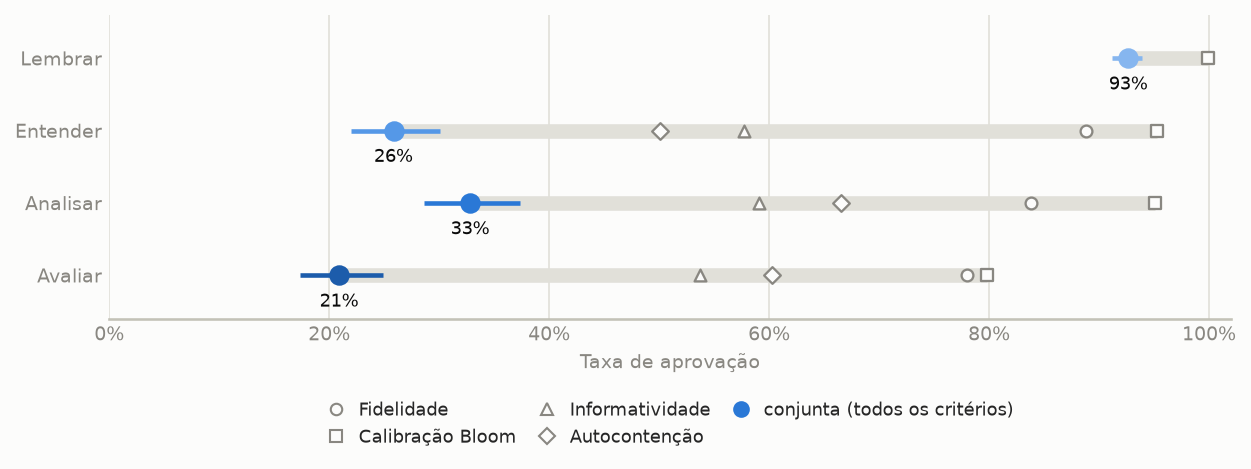

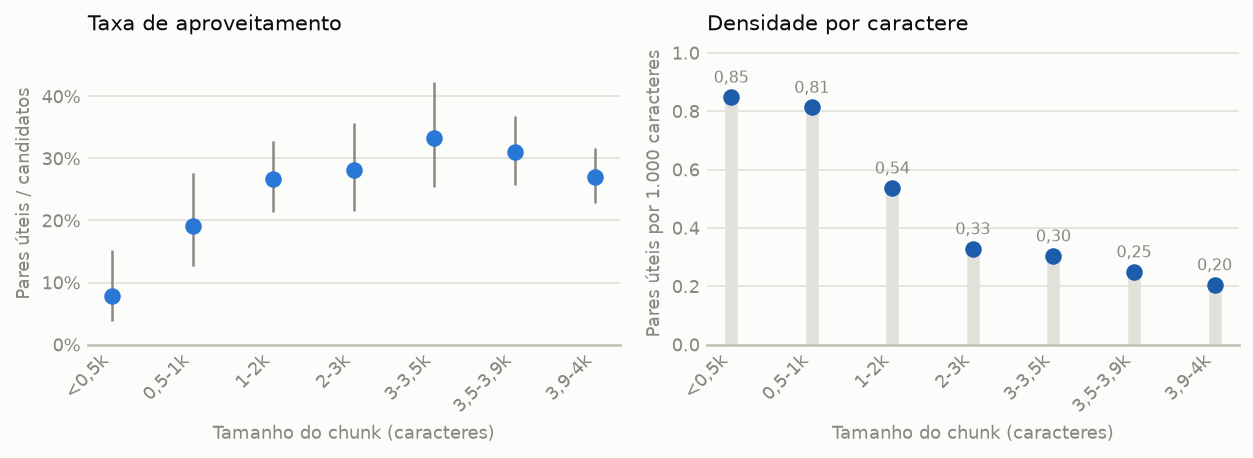

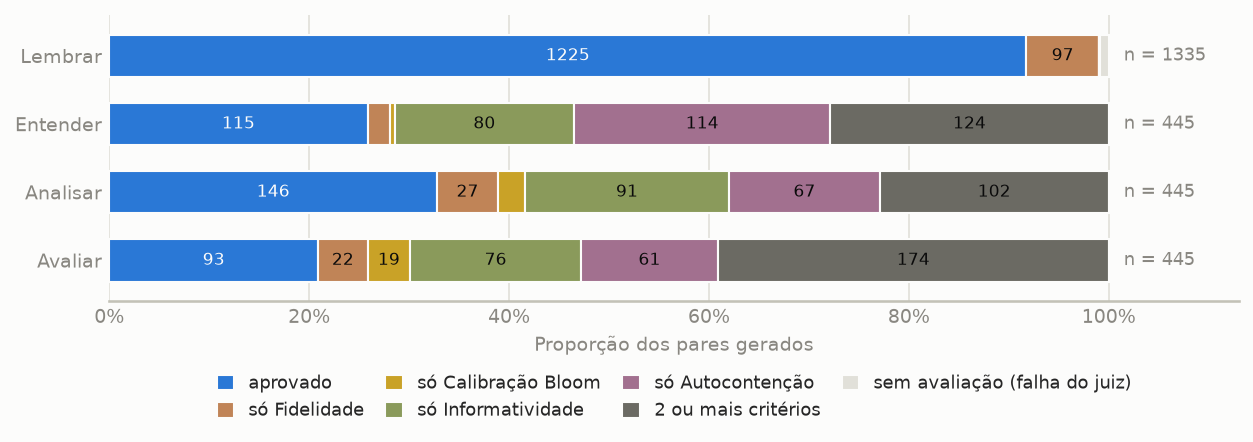

In [18]:
# Figuras para artigo: mesmo tratamento da figura de aprovacao (sem titulo, a
# legenda vai no texto).
fig_conjunta_artigo, _ = plot_marginal_vs_joint(approval, joint, figsize=(8.5, 3.4))
caminho_conjunta = FIG_DIR / f"marginal-vs-conjunta-{RUN_ID}.pdf"
fig_conjunta_artigo.savefig(
    caminho_conjunta, facecolor=fig_conjunta_artigo.get_facecolor(), bbox_inches="tight"
)
fig_conjunta_artigo.savefig(
    caminho_conjunta.with_suffix(".png"), dpi=300,
    facecolor=fig_conjunta_artigo.get_facecolor(), bbox_inches="tight",
)

fig_chunk_artigo, _ = plot_chunk_yield(faixas, figsize=(8.5, 3.2))
caminho_chunk = FIG_DIR / f"rendimento-chunk-{RUN_ID}.pdf"
fig_chunk_artigo.savefig(
    caminho_chunk, facecolor=fig_chunk_artigo.get_facecolor(), bbox_inches="tight"
)
fig_chunk_artigo.savefig(
    caminho_chunk.with_suffix(".png"), dpi=300,
    facecolor=fig_chunk_artigo.get_facecolor(), bbox_inches="tight",
)

fig_decomposicao_artigo, _ = plot_rejection_decomposition(decomposicao, figsize=(8.5, 3.2), normalize=True)
caminho_decomposicao = FIG_DIR / f"decomposicao-reprovacao-{RUN_ID}.pdf"
fig_decomposicao_artigo.savefig(
    caminho_decomposicao, facecolor=fig_decomposicao_artigo.get_facecolor(), bbox_inches="tight"
)
fig_decomposicao_artigo.savefig(
    caminho_decomposicao.with_suffix(".png"), dpi=300,
    facecolor=fig_decomposicao_artigo.get_facecolor(), bbox_inches="tight",
)

for caminho in (caminho_conjunta, caminho_chunk, caminho_decomposicao):
    print(f"figura salva em {caminho.relative_to(REPO_ROOT)} (+ .png 300 dpi)")
plt.show()